# REint AI — Wind Forecast Analysis
**Part 2: Error Analysis & Reliability Recommendation**

In [1]:
import requests, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14,5), 'axes.spines.top': False, 'axes.spines.right': False})
BASE = 'https://data.elexon.co.uk/bmrs/api/v1'
print('Ready ✓')

Ready ✓


## 1. Fetch Data

In [2]:
def fetch_stream(url, params):
    """Fetch from Elexon stream endpoint. Returns a flat list of dicts."""
    r = requests.get(url, params=params, timeout=60)
    print(f'  status={r.status_code} | chars={len(r.text)}')
    if r.status_code != 200:
        return []
    rows = []
    for line in r.text.strip().split('\n'):
        line = line.strip()
        if not line:
            continue
        try:
            parsed = json.loads(line)
            if isinstance(parsed, list):
                # Each item in the list could be a dict or another list
                for item in parsed:
                    if isinstance(item, dict):
                        rows.append(item)
                    elif isinstance(item, list):
                        rows.extend([x for x in item if isinstance(x, dict)])
            elif isinstance(parsed, dict):
                rows.append(parsed)
        except:
            pass
    return rows

weeks = [
    ('2024-01-01','2024-01-07'),
    ('2024-01-08','2024-01-14'),
    ('2024-01-15','2024-01-21'),
    ('2024-01-22','2024-01-31'),
]

print('=== ACTUAL ===')
all_actual = []
for d1, d2 in weeks:
    rows = fetch_stream(f'{BASE}/datasets/FUELHH/stream',
                        {'settlementDateFrom': d1, 'settlementDateTo': d2, 'fuelType': 'WIND'})
    all_actual.extend(rows)
    print(f'  → week {d1}: {len(rows)} dicts')

print(f'\nTotal actual dicts: {len(all_actual)}')
if all_actual:
    print('Type of first item:', type(all_actual[0]))
    print('First item:', all_actual[0])

=== ACTUAL ===
  status=200 | chars=60827
  → week 2024-01-01: 336 dicts
  status=200 | chars=60852
  → week 2024-01-08: 336 dicts
  status=200 | chars=60969
  → week 2024-01-15: 336 dicts
  status=200 | chars=87133
  → week 2024-01-22: 480 dicts

Total actual dicts: 1488
Type of first item: <class 'dict'>
First item: {'dataset': 'FUELHH', 'publishTime': '2024-01-08T00:00:00Z', 'startTime': '2024-01-07T23:30:00Z', 'settlementDate': '2024-01-07', 'settlementPeriod': 48, 'fuelType': 'WIND', 'generation': 4275}


In [3]:
print('=== FORECAST ===')
all_forecast = []
for d1, d2 in weeks:
    rows = fetch_stream(f'{BASE}/datasets/WINDFOR/stream',
                        {'publishDateTimeFrom': d1, 'publishDateTimeTo': d2})
    all_forecast.extend(rows)
    print(f'  → week {d1}: {len(rows)} dicts')

print(f'\nTotal forecast dicts: {len(all_forecast)}')
if all_forecast:
    print('First item:', all_forecast[0])

=== FORECAST ===
  status=200 | chars=263940
  → week 2024-01-01: 2352 dicts
  status=200 | chars=263829
  → week 2024-01-08: 2352 dicts
  status=200 | chars=265162
  → week 2024-01-15: 2352 dicts
  status=200 | chars=397841
  → week 2024-01-22: 3528 dicts

Total forecast dicts: 10584
First item: {'dataset': 'WINDFOR', 'publishTime': '2024-01-06T22:30:00Z', 'startTime': '2024-01-06T21:00:00Z', 'generation': 5909}


## 2. Build DataFrames

In [4]:
# --- Actual ---
# all_actual is now guaranteed to be a list of dicts
actual = pd.DataFrame(all_actual)
print('Actual columns:', actual.columns.tolist())
print(actual.head(2))

actual = actual[['startTime', 'generation']].copy()
actual.columns = ['time', 'actual_mw']
actual['time']      = pd.to_datetime(actual['time'], utc=True)
actual['actual_mw'] = pd.to_numeric(actual['actual_mw'], errors='coerce')
actual = actual.dropna().sort_values('time').drop_duplicates('time').set_index('time')
print(f'\nActual shape: {actual.shape}')
actual.head(3)

Actual columns: ['dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']
  dataset           publishTime             startTime settlementDate  \
0  FUELHH  2024-01-08T00:00:00Z  2024-01-07T23:30:00Z     2024-01-07   
1  FUELHH  2024-01-07T23:30:00Z  2024-01-07T23:00:00Z     2024-01-07   

   settlementPeriod fuelType  generation  
0                48     WIND        4275  
1                47     WIND        4242  

Actual shape: (1488, 1)


,actual_mw
time,
2024-01-01 00:00:00+00:00,10402
2024-01-01 00:30:00+00:00,10845
2024-01-01 01:00:00+00:00,11218


In [5]:
# --- Forecast ---
forecast = pd.DataFrame(all_forecast)
print('Forecast columns:', forecast.columns.tolist())
print(forecast.head(2))

forecast = forecast[['startTime', 'publishTime', 'generation']].copy()
forecast.columns = ['target_time', 'publish_time', 'forecast_mw']
forecast['target_time']  = pd.to_datetime(forecast['target_time'],  utc=True)
forecast['publish_time'] = pd.to_datetime(forecast['publish_time'], utc=True)
forecast['forecast_mw']  = pd.to_numeric(forecast['forecast_mw'],  errors='coerce')
forecast['horizon_h'] = (forecast['target_time'] - forecast['publish_time']).dt.total_seconds() / 3600
forecast = forecast.dropna()
print(f'\nForecast shape: {forecast.shape}')
print(f'Horizon range: {forecast.horizon_h.min():.1f}h – {forecast.horizon_h.max():.1f}h')
forecast.head(3)

Forecast columns: ['dataset', 'publishTime', 'startTime', 'generation']
   dataset           publishTime             startTime  generation
0  WINDFOR  2024-01-06T22:30:00Z  2024-01-06T21:00:00Z        5909
1  WINDFOR  2024-01-06T22:30:00Z  2024-01-06T22:00:00Z        5996

Forecast shape: (10584, 4)
Horizon range: -1.5h – 66.5h


,target_time,publish_time,forecast_mw,horizon_h
0,2024-01-06 21:00:00+00:00,2024-01-06 22:30:00+00:00,5909,-1.5
1,2024-01-06 22:00:00+00:00,2024-01-06 22:30:00+00:00,5996,-0.5
2,2024-01-06 23:00:00+00:00,2024-01-06 22:30:00+00:00,6149,0.5


## 3. Match at 4h Horizon

In [6]:
def best_forecast(fc, h=4):
    valid = fc[fc.horizon_h >= h].sort_values('publish_time')
    return valid.groupby('target_time').last()[['forecast_mw']]

fc4 = best_forecast(forecast, 4)
df  = actual.join(fc4, how='inner')
df['error']     = df['forecast_mw'] - df['actual_mw']
df['abs_error'] = df['error'].abs()
df['hour']      = df.index.hour
print(f'Matched rows: {len(df)}')
df.head()

Matched rows: 723


,actual_mw,forecast_mw,error,abs_error,hour
2024-01-01 21:00:00+00:00,13953,10634,-3319,3319,21
2024-01-01 22:00:00+00:00,14217,11767,-2450,2450,22
2024-01-01 23:00:00+00:00,14958,14419,-539,539,23
2024-01-02 00:00:00+00:00,14690,15361,671,671,0
2024-01-02 01:00:00+00:00,14592,15805,1213,1213,1


## 4. Error Characteristics

Mean Error    : +1,250 MW
Median Error  : +1,073 MW
P99 Abs Error : 6,738 MW
MAE           : 1,879 MW
RMSE          : 2,492 MW


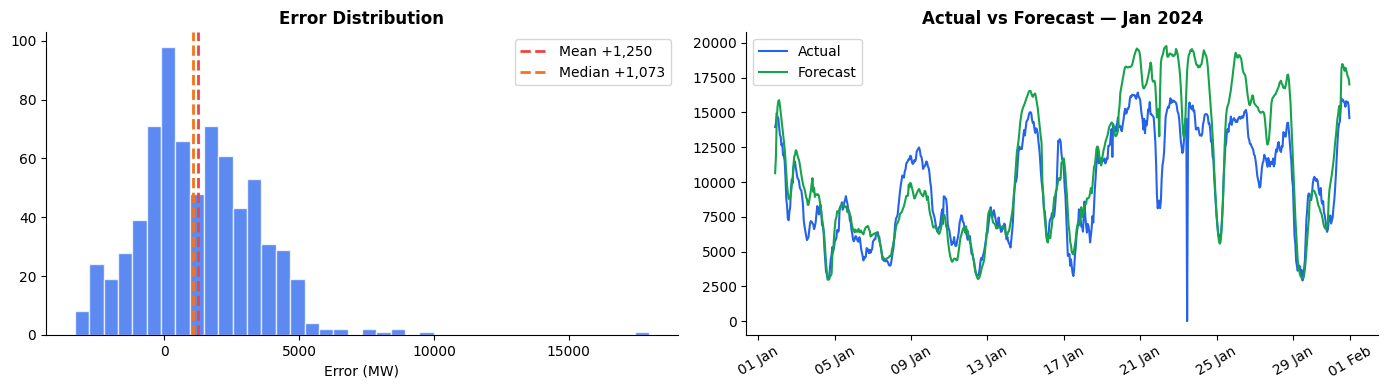

In [7]:
mean_err = df['error'].mean()
med_err  = df['error'].median()
p99_err  = df['abs_error'].quantile(0.99)
mae      = df['abs_error'].mean()
rmse     = np.sqrt((df['error']**2).mean())

print(f'Mean Error    : {mean_err:+,.0f} MW')
print(f'Median Error  : {med_err:+,.0f} MW')
print(f'P99 Abs Error : {p99_err:,.0f} MW')
print(f'MAE           : {mae:,.0f} MW')
print(f'RMSE          : {rmse:,.0f} MW')

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].hist(df['error'], bins=40, color='#2563eb', alpha=0.75, edgecolor='white')
axes[0].axvline(mean_err, color='#ef4444', lw=2, ls='--', label=f'Mean {mean_err:+,.0f}')
axes[0].axvline(med_err,  color='#f97316', lw=2, ls='--', label=f'Median {med_err:+,.0f}')
axes[0].set_title('Error Distribution', fontweight='bold')
axes[0].set_xlabel('Error (MW)'); axes[0].legend()
axes[1].plot(df.index, df['actual_mw'],   color='#2563eb', lw=1.5, label='Actual')
axes[1].plot(df.index, df['forecast_mw'], color='#16a34a', lw=1.5, label='Forecast')
axes[1].set_title('Actual vs Forecast — Jan 2024', fontweight='bold')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].legend(); plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Error vs Horizon

    h          mae         rmse         bias
0   1  1874.966805  2485.393480  1250.330567
1   2  1874.593361  2485.313852  1250.012448
2   4  1879.265560  2491.698701  1249.686030
3   6  1886.477178  2498.847083  1241.323651
4  12  1909.565698  2522.172374  1232.600277
5  24  1993.356125  2598.994154  1358.538462
6  36  2051.290520  2530.488289  1464.529052
7  48  2382.214575  2779.816914  1635.866397


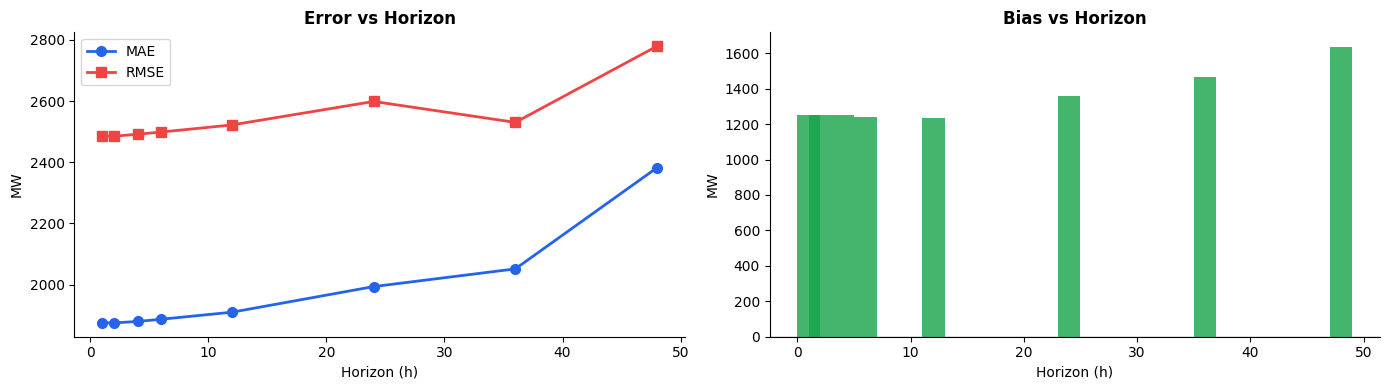

In [8]:
hs = []
for h in [1, 2, 4, 6, 12, 24, 36, 48]:
    m = actual.join(best_forecast(forecast, h), how='inner')
    if len(m) < 5: continue
    e = m['forecast_mw'] - m['actual_mw']
    hs.append({'h': h, 'mae': e.abs().mean(), 'rmse': np.sqrt((e**2).mean()), 'bias': e.mean()})
hs = pd.DataFrame(hs)
print(hs)

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(hs.h, hs.mae,  'o-', color='#2563eb', lw=2, ms=7, label='MAE')
axes[0].plot(hs.h, hs.rmse, 's-', color='#ef4444', lw=2, ms=7, label='RMSE')
axes[0].set_title('Error vs Horizon', fontweight='bold')
axes[0].set_xlabel('Horizon (h)'); axes[0].set_ylabel('MW'); axes[0].legend()
axes[1].bar(hs.h, hs.bias, color=['#16a34a' if x>=0 else '#ef4444' for x in hs.bias], alpha=0.8, width=2)
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_title('Bias vs Horizon', fontweight='bold')
axes[1].set_xlabel('Horizon (h)'); axes[1].set_ylabel('MW')
plt.tight_layout()
plt.savefig('horizon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error by Hour of Day

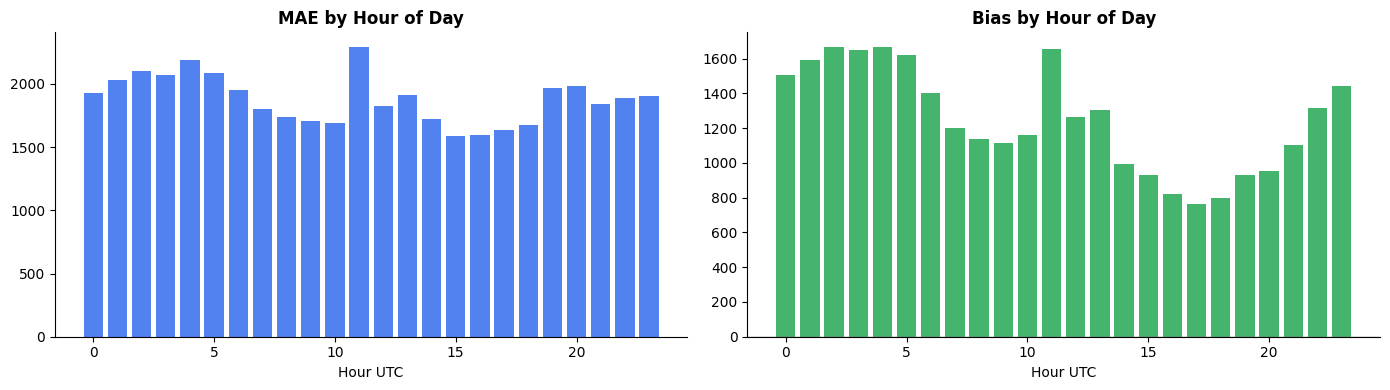

In [9]:
hr = df.groupby('hour').agg(mae=('abs_error','mean'), bias=('error','mean')).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].bar(hr.hour, hr.mae,  color='#2563eb', alpha=0.8)
axes[0].set_title('MAE by Hour of Day', fontweight='bold'); axes[0].set_xlabel('Hour UTC')
axes[1].bar(hr.hour, hr.bias, color=['#16a34a' if x>=0 else '#ef4444' for x in hr.bias], alpha=0.8)
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_title('Bias by Hour of Day', fontweight='bold'); axes[1].set_xlabel('Hour UTC')
plt.tight_layout()
plt.savefig('hourly_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Generation Stats & Reliable MW Recommendation

=== GENERATION STATS — Jan 2024 ===
  Mean    : 9,849 MW
  Median  : 9,864 MW
  Min     : 0 MW
  Max     : 16,662 MW
  P10     : 5,088 MW
  P25     : 6,732 MW
  P75     : 13,105 MW
  P90     : 14,810 MW

=== RELIABLE MW RECOMMENDATION ===
  MAE at 4h horizon      : 1,879 MW
  Conservative (P10-MAE) : 3,209 MW
  Moderate (P25-0.5*MAE) : 5,793 MW

REASONING:
  Jan 2024 wind generation ranged 0–16,662 MW.
  P10 = 5,088 MW was exceeded 90% of the time.
  At 4h forecast horizon, MAE = 1,879 MW.
  Conservative committable capacity ≈ 3,209 MW (P10 minus full MAE buffer).
  Moderate committable capacity ≈ 5,793 MW (P25 minus half MAE buffer).



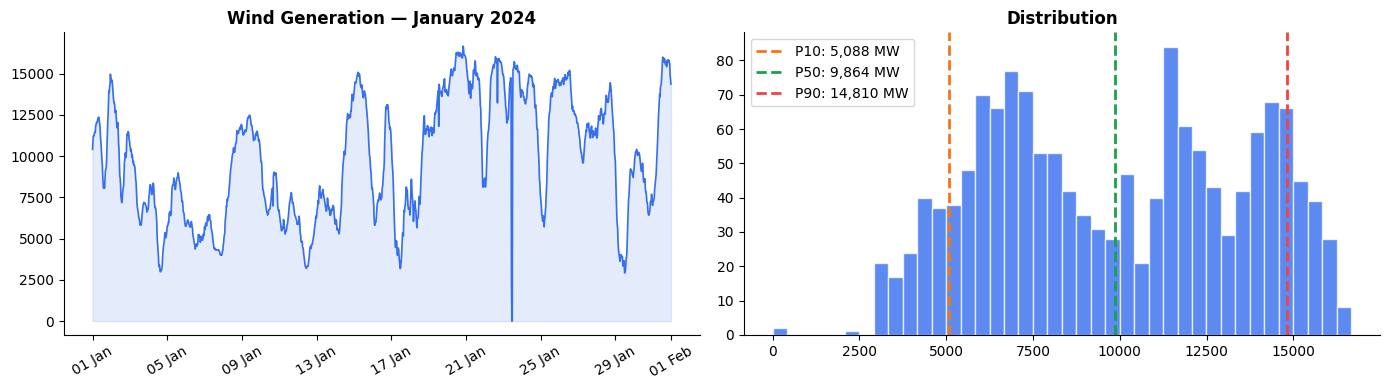

In [10]:
p10 = actual['actual_mw'].quantile(0.10)
p25 = actual['actual_mw'].quantile(0.25)
conservative = p10 - mae
moderate     = p25 - mae * 0.5

print('=== GENERATION STATS — Jan 2024 ===')
for lbl, v in [('Mean',   actual['actual_mw'].mean()),
               ('Median', actual['actual_mw'].median()),
               ('Min',    actual['actual_mw'].min()),
               ('Max',    actual['actual_mw'].max()),
               ('P10',    p10), ('P25', p25),
               ('P75',    actual['actual_mw'].quantile(0.75)),
               ('P90',    actual['actual_mw'].quantile(0.90))]:
    print(f'  {lbl:<8}: {v:,.0f} MW')

print(f'\n=== RELIABLE MW RECOMMENDATION ===')
print(f'  MAE at 4h horizon      : {mae:,.0f} MW')
print(f'  Conservative (P10-MAE) : {conservative:,.0f} MW')
print(f'  Moderate (P25-0.5*MAE) : {moderate:,.0f} MW')
print(f"""
REASONING:
  Jan 2024 wind generation ranged {actual['actual_mw'].min():,.0f}–{actual['actual_mw'].max():,.0f} MW.
  P10 = {p10:,.0f} MW was exceeded 90% of the time.
  At 4h forecast horizon, MAE = {mae:,.0f} MW.
  Conservative committable capacity ≈ {conservative:,.0f} MW (P10 minus full MAE buffer).
  Moderate committable capacity ≈ {moderate:,.0f} MW (P25 minus half MAE buffer).
""")

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(actual.index, actual['actual_mw'], color='#2563eb', lw=1.2, alpha=0.9)
axes[0].fill_between(actual.index, actual['actual_mw'], alpha=0.12, color='#2563eb')
axes[0].set_title('Wind Generation — January 2024', fontweight='bold')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)
axes[1].hist(actual['actual_mw'], bins=40, color='#2563eb', alpha=0.75, edgecolor='white')
for p, c, l in [(0.10,'#f97316','P10'),(0.50,'#16a34a','P50'),(0.90,'#ef4444','P90')]:
    v = actual['actual_mw'].quantile(p)
    axes[1].axvline(v, color=c, lw=2, ls='--', label=f'{l}: {v:,.0f} MW')
axes[1].set_title('Distribution', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.savefig('generation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()